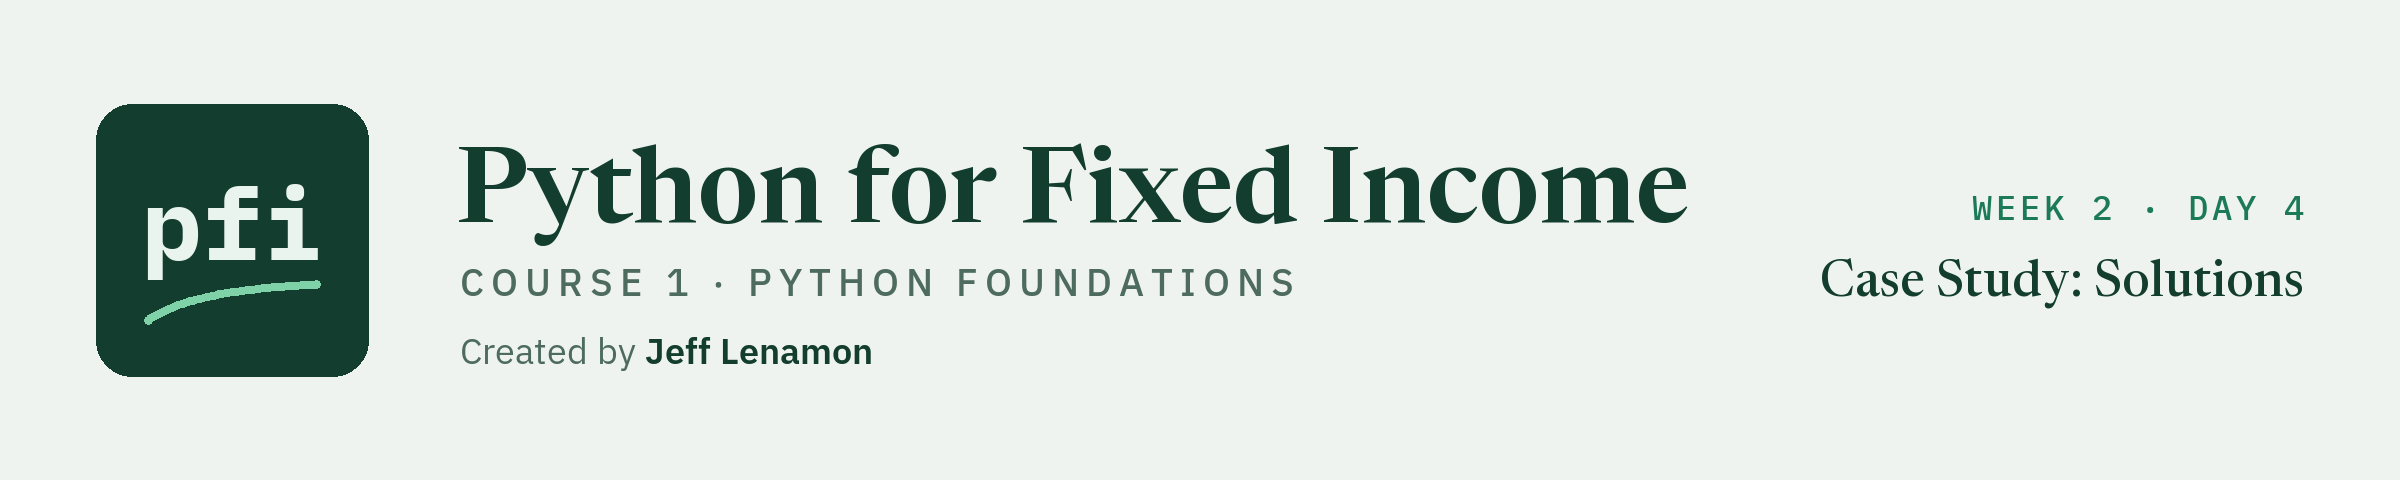

# Case Study: A First Look at the Data - Solutions

Week 2. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week2/day4/09_case_study_first_look_at_the_data_solutions.ipynb)

## Exercises

A fourth file has arrived: `benchmark.csv`, the benchmark the portfolio is measured against. It has one row per benchmark bond, with a `cusip`, a `ticker`, and a `rating` among its columns. Give it the same first look, and check it against the three tables you now know. The issuers are invented.

Replace each `...` with your own code, then run the check cell under it. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports pandas, loads the benchmark as `benchmark` with fresh copies of `positions`, `issuers`, and `ratings`, and defines `check`, a small function that marks your answers.

In [1]:
import os

import pandas as pd


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, list):
        # a list of values: the same values in the same order
        correct = list(answer) == expected
    elif isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# the new file, and fresh copies of the three tables. In Colab they are read from GitHub.
if os.path.exists('../../../data/benchmark.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

benchmark = pd.read_csv(data_folder + 'benchmark.csv')
positions = pd.read_csv(data_folder + 'positions.csv')
issuers = pd.read_csv(data_folder + 'issuers.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')
print(len(benchmark), len(positions), len(issuers), len(ratings))

821 200 150 18


### Exercise 1

Q. How large is the benchmark table? How many of its columns are text? Store the shape in **ex1_shape** and the number of text columns in **ex1_text_columns**. For the second answer, print the data types and count by eye.

In [2]:
ex1_shape = benchmark.shape
print(ex1_shape)

# the type of every column. Text is str in pandas 3 and object in older versions.
print(benchmark.dtypes)

# counted from the list above: as_of_date, cusip, ticker, issuer, sector, rating, maturity, price_date
ex1_text_columns = 8

(821, 19)
as_of_date                str
cusip                     str
ticker                    str
issuer                    str
sector                    str
rating                    str
coupon                float64
maturity                  str
price                 float64
price_date                str
accrued               float64
yield_pct             float64
oas                     int64
duration              float64
spread_duration       float64
dts                   float64
amount_outstanding      int64
market_value          float64
weight_pct            float64
dtype: object


* 821 rows and 19 columns. Eight columns are text, and three of those are dates stored as text: `as_of_date`, `maturity`, and `price_date`. The other eleven are numbers.

In [3]:
check('Exercise 1 shape', ex1_shape, (821, 19))
check('Exercise 1 text columns', ex1_text_columns, 8)

Exercise 1 shape: correct
Exercise 1 text columns: correct


### Exercise 2

Q. How many values are missing in the whole benchmark table? How many rows are exact copies of an earlier row? Is the CUSIP unique? Store the answers in **ex2_missing**, **ex2_duplicates**, and **ex2_cusip_unique**.

In [4]:
# missing values per column, then added into one number
ex2_missing = benchmark.isna().sum().sum()

# rows that repeat an earlier row
ex2_duplicates = benchmark.duplicated().sum()

# True when no CUSIP appears twice
ex2_cusip_unique = benchmark['cusip'].is_unique

print('Missing values:', ex2_missing)
print('Duplicate rows:', ex2_duplicates)
print('CUSIP unique:', ex2_cusip_unique)

Missing values: 0
Duplicate rows: 0
CUSIP unique: True


* Nothing is missing, no row is repeated, and each of the 821 CUSIPs appears once. One row of the benchmark is one bond, identified by its CUSIP.

In [5]:
check('Exercise 2 missing', ex2_missing, 0)
check('Exercise 2 duplicates', ex2_duplicates, 0)
check('Exercise 2 CUSIP unique', ex2_cusip_unique, True)

Exercise 2 missing: correct
Exercise 2 duplicates: correct
Exercise 2 CUSIP unique: correct


### Exercise 3

Q. How many distinct tickers does the benchmark have? What is the largest number of bonds any one ticker has? Does every benchmark ticker exist in the issuers table? Store the answers in **ex3_tickers**, **ex3_most_bonds**, and **ex3_all_found**.

In [6]:
ex3_tickers = benchmark['ticker'].nunique()

# value_counts() puts the most frequent ticker first, so the largest count is the maximum
ex3_most_bonds = benchmark['ticker'].value_counts().max()

# one True or False per benchmark bond, then all() asks whether every one is True
ex3_all_found = benchmark['ticker'].isin(issuers['ticker']).all()

print('Distinct tickers:', ex3_tickers)
print('Most bonds for one ticker:', ex3_most_bonds)
print('Every ticker found in issuers:', ex3_all_found)

Distinct tickers: 150
Most bonds for one ticker: 8
Every ticker found in issuers: True


* 150 distinct tickers across 821 bonds, with at most 8 bonds for one ticker. Every benchmark ticker is in the issuers table. The benchmark has 150 tickers and the issuers table has 150 rows, so the benchmark covers every issuer in the reference data.

In [7]:
check('Exercise 3 tickers', ex3_tickers, 150)
check('Exercise 3 most bonds', ex3_most_bonds, 8)
check('Exercise 3 all found', ex3_all_found, True)

Exercise 3 tickers: correct
Exercise 3 most bonds: correct
Exercise 3 all found: correct


### Exercise 4

Q. A bond is identified by its CUSIP. Does every CUSIP in the positions exist in the benchmark? How many benchmark bonds does the desk hold, and how many does it not hold? Store the answers in **ex4_all_found**, **ex4_held**, and **ex4_not_held**. Use `isin()`, without a merge.

In [8]:
# every position, tested against the benchmark's CUSIPs
ex4_all_found = positions['cusip'].isin(benchmark['cusip']).all()

# every benchmark bond, tested against the desk's CUSIPs
held = benchmark['cusip'].isin(positions['cusip'])
ex4_held = held.sum()
ex4_not_held = (~held).sum()

print('Every position found in the benchmark:', ex4_all_found)
print('Benchmark bonds held:', ex4_held)
print('Benchmark bonds not held:', ex4_not_held)

Every position found in the benchmark: True
Benchmark bonds held: 200
Benchmark bonds not held: 621


* Every one of the desk's 200 CUSIPs is a benchmark bond. Of the 821 benchmark bonds the desk holds 200 and does not hold 621. Yesterday a merge gave the same two counts. `isin()` gets them without building a joined table.

In [9]:
check('Exercise 4 all found', ex4_all_found, True)
check('Exercise 4 held', ex4_held, 200)
check('Exercise 4 not held', ex4_not_held, 621)

Exercise 4 all found: correct
Exercise 4 held: correct
Exercise 4 not held: correct


### Exercise 5: AI check

You ask an AI assistant how many benchmark bonds the desk does not hold. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It contains one bug.

Q. Read the code before you run it. What number do you expect? You worked it out yourself in Exercise 4. Then run the code. Does it agree with you?

* The answer from Exercise 4 is 621. The original code printed 159, with no error.
* The bug was the column. The code tested the benchmark's `ticker` against the desk's tickers, so it marked a bond as held whenever the desk holds any bond of the same issuer. A bond is identified by its CUSIP, and the ticker repeats: 150 tickers cover the 821 benchmark bonds.
* 159 is a real count of something else: the benchmark bonds of the 35 issuers the desk does not hold at all. The code answered a different question from the one asked, and nothing in the output said so.
* The check that catches it is the one from section 5.1: before matching two tables on a column, ask whether that column identifies one row.

In [10]:
# True for each benchmark bond whose CUSIP is in the desk's positions
held = benchmark['cusip'].isin(positions['cusip'])

# the bonds not held are the ones where held is False
ex5_not_held = (~held).sum()

print('Benchmark bonds the desk does not hold:', ex5_not_held)

Benchmark bonds the desk does not hold: 621


In [11]:
check('Exercise 5 not held', ex5_not_held, 621)

Exercise 5 not held: correct
